# Dark Pattern Detection
**End-to-end pipeline:** Scrape → Features → ML Model → Regulation Mapping → Remediation → Power BI Export

### Install required libraries (run once)
```
pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn playwright nest_asyncio
playwright install chromium
```

In [1]:
# Run this cell once to install everything
import subprocess, sys
packages = ['pandas','numpy','scikit-learn','xgboost','shap','matplotlib','seaborn','playwright','nest_asyncio']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)
subprocess.run([sys.executable, '-m', 'playwright', 'install', 'chromium'], check=False)
print('All libraries installed.')

All libraries installed.


## Section 1 — Imports

In [2]:
import re
import sys
import asyncio
import warnings
import nest_asyncio
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier
import shap

# Windows + Jupyter fix — must be before any asyncio usage
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
nest_asyncio.apply()

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
SEED = 42
np.random.seed(SEED)
print('Setup complete.')

Setup complete.


## Section 2 — Data Collection

Set `SCRAPE = True` to collect real data from 15 Indian/global e-commerce sites.  
Set `SCRAPE = False` to use the built-in sample dataset and skip to Section 3.

In [3]:
import sys
print(sys.executable)

C:\Users\dell\anaconda3\python.exe


In [4]:
import sys
import asyncio

if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

SCRAPE = False  # Change to True when ready to scrape

TARGET_SITES = [
    {'site': 'booking_com',  'url': 'https://www.booking.com',          'sector': 'travel'},
    {'site': 'expedia',      'url': 'https://www.expedia.com/Hotels',    'sector': 'travel'},
    {'site': 'makemytrip',   'url': 'https://www.makemytrip.com',        'sector': 'travel'},
    {'site': 'cleartrip',    'url': 'https://www.cleartrip.com',         'sector': 'travel'},
    {'site': 'amazon',       'url': 'https://www.amazon.in/s?k=laptop',  'sector': 'retail'},
    {'site': 'flipkart',     'url': 'https://www.flipkart.com/laptops',  'sector': 'retail'},
    {'site': 'myntra',       'url': 'https://www.myntra.com',            'sector': 'retail'},
    {'site': 'ajio',         'url': 'https://www.ajio.com',              'sector': 'retail'},
    {'site': 'nykaa',        'url': 'https://www.nykaa.com',             'sector': 'retail'},
    {'site': 'meesho',       'url': 'https://www.meesho.com',            'sector': 'retail'},
    {'site': 'bigbasket',    'url': 'https://www.bigbasket.com',         'sector': 'retail'},
    {'site': 'netflix',      'url': 'https://www.netflix.com/in',        'sector': 'saas'},
    {'site': 'hotstar',      'url': 'https://www.hotstar.com',           'sector': 'saas'},
    {'site': 'swiggy',       'url': 'https://www.swiggy.com',            'sector': 'food'},
    {'site': 'zomato',       'url': 'https://www.zomato.com',            'sector': 'food'},
]


async def extract_ui_text(page):
    try:
        items = await page.evaluate("""
            () => {
                const selectors = [
                    'button', '[role="button"]', 'input[type="submit"]',
                    'a[href]', 'label', '[class*="decline"]',
                    '[class*="cookie"] button', '[class*="banner"] button',
                    '[class*="urgency"]', '[class*="scarcity"]', '[class*="timer"]'
                ];
                const elements = document.querySelectorAll(selectors.join(','));
                return Array.from(elements)
                    .map(el => (el.innerText || el.value || '').trim())
                    .filter(t => t.length > 2 && t.length < 200);
            }
        """)
        return list(set(items))
    except Exception:
        return []


async def scrape_all():
    from playwright.async_api import async_playwright
    records = []
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        for target in TARGET_SITES:
            try:
                page = await browser.new_page()
                await page.set_extra_http_headers({'User-Agent': 'Mozilla/5.0'})
                await page.goto(target['url'], wait_until='domcontentloaded', timeout=25000)
                await page.wait_for_timeout(2000)
                texts = await extract_ui_text(page)
                for txt in texts:
                    records.append({
                        'site':         target['site'],
                        'sector':       target['sector'],
                        'url':          target['url'],
                        'ui_text':      txt,
                        'scraped_date': str(date.today())
                    })
                print(f'[OK] {target["site"]:15} — {len(texts)} UI texts')
                await page.close()
            except Exception as e:
                print(f'[ERR] {target["site"]}: {e}')
        await browser.close()
    return pd.DataFrame(records)


if SCRAPE:
    print('Starting scraper... (takes 2-4 minutes)')
    loop = asyncio.get_event_loop()
    raw_df = loop.run_until_complete(scrape_all())
    raw_df.to_csv('dark_pattern_scraped.csv', index=False)
    print(f'\nSaved {len(raw_df)} rows to dark_pattern_scraped.csv')
    df = raw_df.copy()
else:
    print('Scraping skipped. Loading dataset in next cell.')

Scraping skipped. Loading dataset in next cell.


In [5]:
csv_path = Path('dark_pattern_scraped.csv')

if csv_path.exists():
    df = pd.read_csv(csv_path)
    # Add empty label columns if not already present
    label_cols_needed = ['label_urgency','label_confirmshaming','label_hidden_costs',
                         'label_trick_question','label_roach_motel','label_misdirection']
    for col in label_cols_needed:
        if col not in df.columns:
            df[col] = np.nan
    print(f'Loaded: {len(df)} rows from dark_pattern_scraped.csv')
    print(f'Labelled rows: {df[label_cols_needed].notna().all(axis=1).sum()}')
else:
    # Built-in sample dataset
    df = pd.DataFrame({
        'site': [
            'TravelDeal','TravelDeal','TravelDeal','TravelDeal','TravelDeal',
            'ShopFlash','ShopFlash','ShopFlash','ShopFlash',
            'BookNow','BookNow','BookNow','BookNow',
            'SubscribeBox','SubscribeBox','SubscribeBox','SubscribeBox',
            'MegaStore','MegaStore','MegaStore',
            'CloudPass','CloudPass','CloudPass',
            'FashionForward','FashionForward','FashionForward',
            'TechGadgets','TechGadgets',
            'StreamPro','StreamPro',
            'CleanMart','CleanMart'
        ],
        'sector': [
            'travel','travel','travel','travel','travel',
            'retail','retail','retail','retail',
            'travel','travel','travel','travel',
            'saas','saas','saas','saas',
            'retail','retail','retail',
            'saas','saas','saas',
            'retail','retail','retail',
            'retail','retail',
            'saas','saas',
            'retail','retail'
        ],
        'url': ['https://example.com'] * 32,
        'ui_text': [
            'Only 2 seats left at this price!',
            'Deal expires in 00:09:47 book now',
            'No thanks I hate saving money',
            'Resort fee $34.99 added at checkout',
            'Hurry 7 people viewing this deal',
            'Flash sale ends TODAY 80% off',
            'Sign me up for weekly newsletters pre-checked',
            'Only 3 left in stock order soon',
            'No I prefer to pay full price',
            'Last room available at this rate',
            'Price shown excludes taxes and service fees',
            'No thanks I dont want free upgrades',
            'Booking fee $12.50 added at step 4 of 4',
            'Cancel anytime requires 30-day written notice',
            'No thanks I dont want to grow my business',
            'Auto-renew enabled pre-checked',
            'Upgrade now limited offer ends midnight',
            'Selling fast 5 left in stock',
            'Add protection plan $19.99 pre-selected',
            'Taxes and import fees calculated at checkout',
            'Limited edition act now before its gone',
            'Shipping fees added at final step',
            'Cancel by calling our retention team only',
            'Add warranty for $14.99 already checked',
            'We will email you promotions opt-out buried in settings',
            'Limited time offer expires soon act fast',
            'Shop our new summer arrivals',
            'Standard delivery 3-5 business days free over $50',
            'Fresh produce no hidden fees',
            'Easy returns no questions asked',
            'Cancel anytime from your account settings',
            'Price includes all taxes and fees'
        ],
        'label_urgency':        [1,1,0,0,1, 1,0,1,0, 0,0,0,0, 0,0,0,1, 1,0,0, 1,0,0, 0,0,1, 0,0, 0,0, 0,0],
        'label_confirmshaming': [0,0,1,0,0, 0,0,0,1, 0,0,1,0, 0,1,0,0, 0,0,0, 0,0,0, 0,0,0, 0,0, 0,0, 0,0],
        'label_hidden_costs':   [0,0,0,1,0, 0,0,0,0, 0,1,0,1, 0,0,0,0, 0,0,1, 0,1,0, 0,0,0, 0,0, 0,0, 0,0],
        'label_trick_question': [0,0,0,0,0, 0,1,0,0, 0,0,0,0, 0,0,1,0, 0,1,0, 0,0,0, 1,0,0, 0,0, 0,0, 0,0],
        'label_roach_motel':    [0,0,0,0,0, 0,0,0,0, 0,0,0,0, 1,0,0,0, 0,0,0, 0,0,1, 0,0,0, 0,0, 0,0, 0,0],
        'label_misdirection':   [0,0,0,0,0, 0,0,0,0, 0,0,0,0, 0,0,0,0, 0,0,0, 0,0,0, 0,1,0, 0,0, 0,0, 0,0],
        'scraped_date': [str(date.today())] * 32
    })
    print(f'Using built-in sample dataset: {len(df)} rows')

print(f'Columns: {df.columns.tolist()}')
df.head(5)

Loaded: 1077 rows from dark_pattern_scraped.csv
Labelled rows: 1077
Columns: ['site', 'sector', 'url', 'ui_text', 'scraped_date', 'label_urgency', 'label_confirmshaming', 'label_hidden_costs', 'label_trick_question', 'label_roach_motel', 'label_misdirection']


,site,sector,url,ui_text,scraped_date,label_urgency,label_confirmshaming,label_hidden_costs,label_trick_question,label_roach_motel,label_misdirection
0,booking_com,travel,https://www.booking.com,Extranet login,2026-03-18,0,0,0,0,0,0
1,booking_com,travel,https://www.booking.com,Booking.com for Travel Agents,2026-03-18,0,0,0,0,0,0
2,booking_com,travel,https://www.booking.com,Seasonal and holiday deals,2026-03-18,0,0,0,0,0,0
3,booking_com,travel,https://www.booking.com,Oklahoma City hotels,2026-03-18,0,0,0,0,0,0
4,booking_com,travel,https://www.booking.com,São Miguel,2026-03-18,0,0,0,0,0,0


### Labelling guide (only needed after real scraping)

After scraping, open `dark_pattern_scraped.csv` in Excel and add these 6 columns manually:

| Column | Mark 1 if... |
|---|---|
| `label_urgency` | Fake timers, "only N left", "act now" |
| `label_confirmshaming` | Guilt-trip opt-outs like "No thanks, I hate saving" |
| `label_hidden_costs` | Fees revealed only at checkout |
| `label_trick_question` | Pre-checked boxes, auto-enroll |
| `label_roach_motel` | Easy sign-up but hard to cancel |
| `label_misdirection` | Buried reject button, prominent accept |

Label at least 150 rows, then save and re-run from this cell.

## Section 3 — Exploratory Data Analysis

Total rows    : 1077
Labelled rows : 1077


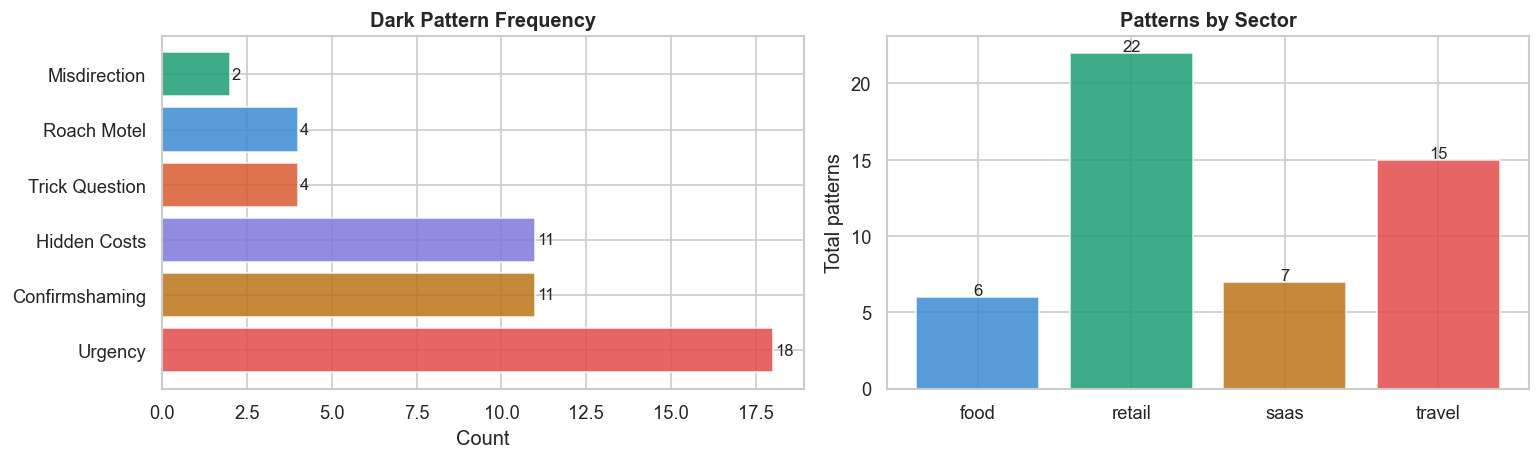

In [6]:
LABEL_COLS = ['label_urgency','label_confirmshaming','label_hidden_costs',
              'label_trick_question','label_roach_motel','label_misdirection']

# Only use labelled rows for EDA and modelling
labelled = df[df[LABEL_COLS].notna().all(axis=1)].copy()
labelled[LABEL_COLS] = labelled[LABEL_COLS].astype(int)

print(f'Total rows    : {len(df)}')
print(f'Labelled rows : {len(labelled)}')

label_counts = labelled[LABEL_COLS].sum().sort_values(ascending=False)
label_names  = [c.replace('label_','').replace('_',' ').title() for c in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#E24B4A','#BA7517','#7F77DD','#D85A30','#3B8BD4','#1D9E75']
axes[0].barh(label_names, label_counts.values, color=colors, alpha=0.85)
axes[0].set_title('Dark Pattern Frequency', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=10)

sector_counts = labelled.groupby('sector')[LABEL_COLS].sum().sum(axis=1)
sector_colors = ['#3B8BD4','#1D9E75','#BA7517','#E24B4A']
axes[1].bar(sector_counts.index, sector_counts.values,
            color=sector_colors[:len(sector_counts)], alpha=0.85)
axes[1].set_title('Patterns by Sector', fontweight='bold')
axes[1].set_ylabel('Total patterns')
for i, (k, v) in enumerate(sector_counts.items()):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Section 4 — Feature Engineering (NLP + Rules)

In [7]:
SEEDS = {
    'urgency':         ['only left act now hurry limited time expires today flash sale selling fast almost gone last chance countdown'],
    'confirmshaming':  ['no thanks i hate saving money i prefer to pay more i dont want deals skip this offer'],
    'hidden_costs':    ['fee added at checkout taxes not included price excludes service charge booking fee resort fee'],
    'trick_question':  ['pre-checked pre-selected already ticked auto-enroll opt-out newsletter checked by default enabled automatically'],
    'roach_motel':     ['cancel by phone call retention team written notice 30 day cancellation difficult contact support to cancel'],
    'misdirection':    ['accept all cookies buried settings hidden option hard to find decline opt-out below the fold'],
}

URGENCY_WORDS = ['only','last','expires','ends','hurry','flash','act now','today only','limited']
GUILT_PHRASES = ["no thanks","i don't want","i dont want","i hate","prefer to pay","skip this"]
COST_SIGNALS  = ['fee','checkout','excludes','not include','taxes','surcharge','added at']
CANCEL_HARD   = ['call','phone','retention','notice','30-day','written','contact support']


def rule_features(text):
    t = text.lower()
    return {
        'urgency_kw':      sum(t.count(w) for w in URGENCY_WORDS),
        'guilt_kw':        sum(1 for p in GUILT_PHRASES if p in t),
        'cost_kw':         sum(t.count(w) for w in COST_SIGNALS),
        'cancel_hard_kw':  sum(t.count(w) for w in CANCEL_HARD),
        'has_countdown':   int(bool(re.search(r'\d+:\d+:\d+|\d+ min', t))),
        'has_num_scarcity':int(bool(re.search(r'only \d+|\d+ (left|remaining)', t))),
        'has_price':       int(bool(re.search(r'\$\d+|rs\.?\s*\d+|inr\s*\d+', t))),
        'has_asterisk':    int('*' in text),
        'has_exclaim':     int('!' in text),
        'word_count':      len(text.split()),
        'uppercase_ratio': sum(1 for c in text if c.isupper()) / max(len(text), 1),
        'has_pre_checked': int(any(w in t for w in ['pre-checked','pre-selected','already checked','auto-renew'])),
    }


def tfidf_similarity_features(texts, seeds_dict):
    result = {}
    texts_list = list(texts)
    for label, seed_list in seeds_dict.items():
        corpus = texts_list + seed_list
        vec = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
        matrix = vec.fit_transform(corpus)
        text_vecs = matrix[:len(texts_list)]
        seed_vecs = matrix[len(texts_list):]
        sims = cosine_similarity(text_vecs, seed_vecs).mean(axis=1)
        result[f'tfidf_{label}'] = sims
    return pd.DataFrame(result)


rule_df  = df['ui_text'].apply(rule_features).apply(pd.Series)
tfidf_df = tfidf_similarity_features(df['ui_text'], SEEDS)
feature_df = pd.concat([rule_df, tfidf_df], axis=1)

print(f'Feature matrix: {feature_df.shape[0]} rows x {feature_df.shape[1]} features')
print(f'Features: {feature_df.columns.tolist()}')
feature_df.head(4)

Feature matrix: 1077 rows x 18 features
Features: ['urgency_kw', 'guilt_kw', 'cost_kw', 'cancel_hard_kw', 'has_countdown', 'has_num_scarcity', 'has_price', 'has_asterisk', 'has_exclaim', 'word_count', 'uppercase_ratio', 'has_pre_checked', 'tfidf_urgency', 'tfidf_confirmshaming', 'tfidf_hidden_costs', 'tfidf_trick_question', 'tfidf_roach_motel', 'tfidf_misdirection']


,urgency_kw,guilt_kw,cost_kw,cancel_hard_kw,has_countdown,has_num_scarcity,has_price,has_asterisk,has_exclaim,word_count,uppercase_ratio,has_pre_checked,tfidf_urgency,tfidf_confirmshaming,tfidf_hidden_costs,tfidf_trick_question,tfidf_roach_motel,tfidf_misdirection
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.071429,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.103448,0.0,0.0,0.000000,0.049358,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.038462,0.0,0.0,0.059167,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.100000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0


## Section 5 — Model Training & Evaluation

In [8]:
labelled_mask = df[LABEL_COLS].notna().all(axis=1)
X = feature_df[labelled_mask].copy()
y = df.loc[labelled_mask, LABEL_COLS].astype(int)

print(f'Training on {len(X)} labelled samples')

if len(X) < 10:
    print('WARNING: Too few labelled samples for a proper split. Using all data for training.')
    X_train, X_test, y_train, y_test = X, X, y, y
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=SEED
    )

model = MultiOutputClassifier(
    XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        base_score=0.5,
        random_state=SEED,
        verbosity=0
    ),
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
per_f1   = f1_score(y_test, y_pred, average=None, zero_division=0)

print(f'\nMacro F1: {macro_f1:.4f}\n')
f1_results = pd.DataFrame({
    'Pattern': [c.replace('label_','').replace('_',' ').title() for c in LABEL_COLS],
    'F1 Score': per_f1.round(3)
}).sort_values('F1 Score', ascending=False)
print(f1_results.to_string(index=False))

Training on 1077 labelled samples

Macro F1: 0.6667

       Pattern  F1 Score
       Urgency       1.0
Confirmshaming       1.0
  Hidden Costs       1.0
   Roach Motel       1.0
Trick Question       0.0
  Misdirection       0.0


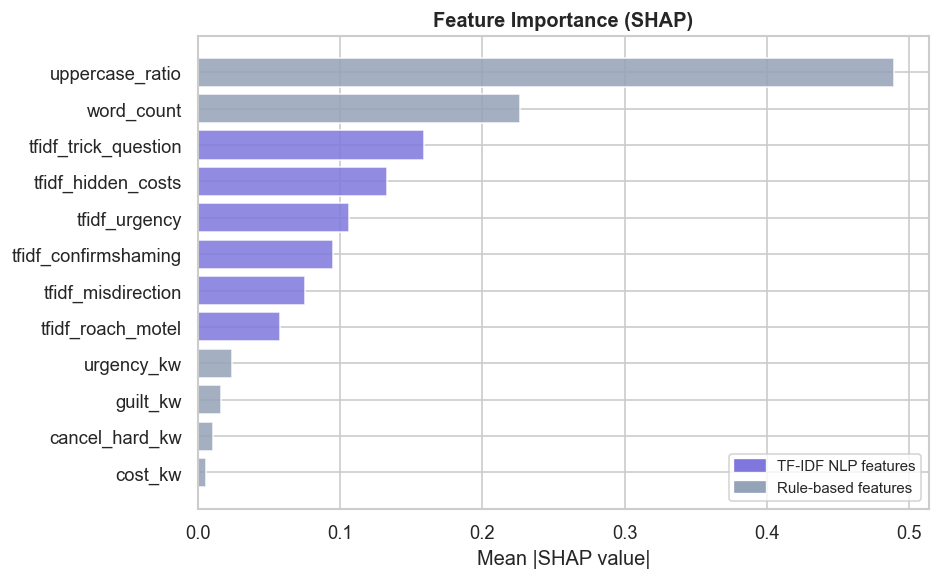

In [9]:
# SHAP feature importance
all_shap = np.zeros(X_test.shape[1])
for est in model.estimators_:
    exp = shap.TreeExplainer(est)
    sv  = np.abs(exp.shap_values(X_test)).mean(axis=0)
    all_shap += sv
all_shap /= len(model.estimators_)

shap_df = pd.DataFrame({'feature': X_test.columns, 'importance': all_shap})\
            .sort_values('importance', ascending=True).tail(12)

bar_colors = ['#7F77DD' if 'tfidf' in f else '#94a3b8' for f in shap_df['feature']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(shap_df['feature'], shap_df['importance'], color=bar_colors, alpha=0.85)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance (SHAP)', fontweight='bold')
legend_p = [
    mpatches.Patch(color='#7F77DD', label='TF-IDF NLP features'),
    mpatches.Patch(color='#94a3b8', label='Rule-based features'),
]
ax.legend(handles=legend_p, fontsize=9)
plt.tight_layout()
plt.show()

## Section 6 — Regulation Mapping

In [10]:
REGULATION_MAP = {
    'label_urgency':        {'pattern': 'Urgency / Scarcity',   'dsa': 'Article 25(1)(a)', 'ftc': 'FTC 2022 — False urgency',          'severity': 'High'},
    'label_confirmshaming': {'pattern': 'Confirmshaming',       'dsa': 'Article 25(1)(b)', 'ftc': 'FTC 2022 — Manipulative opt-outs',   'severity': 'Medium'},
    'label_hidden_costs':   {'pattern': 'Hidden Costs',         'dsa': 'Article 25(1)(c)', 'ftc': 'FTC Act Section 5',                  'severity': 'High'},
    'label_trick_question': {'pattern': 'Trick Questions',      'dsa': 'Article 25(1)(a)', 'ftc': 'FTC 2022 — Pre-checked boxes',       'severity': 'Medium'},
    'label_roach_motel':    {'pattern': 'Roach Motel',          'dsa': 'Article 25(1)(c)', 'ftc': 'FTC Click-to-Cancel Rule 2024',      'severity': 'High'},
    'label_misdirection':   {'pattern': 'Misdirection',         'dsa': 'Article 25(1)(b)', 'ftc': 'FTC 2022 — Buried opt-outs',         'severity': 'Medium'},
}

# Predict on all labelled rows
all_preds = model.predict(X)
pred_df = pd.DataFrame(all_preds, columns=LABEL_COLS, index=df[labelled_mask].index)

findings = []
for idx, row in pred_df.iterrows():
    for col in LABEL_COLS:
        if row[col] == 1:
            reg = REGULATION_MAP[col]
            findings.append({
                'site':     df.loc[idx, 'site'],
                'sector':   df.loc[idx, 'sector'],
                'ui_text':  df.loc[idx, 'ui_text'],
                'pattern':  reg['pattern'],
                'severity': reg['severity'],
                'dsa':      reg['dsa'],
                'ftc':      reg['ftc'],
            })

findings_df = pd.DataFrame(findings) if findings else pd.DataFrame(
    columns=['site','sector','ui_text','pattern','severity','dsa','ftc']
)

print(f'Total findings : {len(findings_df)}')
print(f'High severity  : {len(findings_df[findings_df["severity"]=="High"])}')
findings_df[['site','pattern','severity','dsa']].head(10)

Total findings : 47
High severity  : 31


,site,pattern,severity,dsa
0,booking_com,Urgency / Scarcity,High,Article 25(1)(a)
1,booking_com,Urgency / Scarcity,High,Article 25(1)(a)
2,booking_com,Confirmshaming,Medium,Article 25(1)(b)
3,booking_com,Hidden Costs,High,Article 25(1)(c)
4,booking_com,Urgency / Scarcity,High,Article 25(1)(a)
5,expedia,Urgency / Scarcity,High,Article 25(1)(a)
6,expedia,Hidden Costs,High,Article 25(1)(c)
7,expedia,Confirmshaming,Medium,Article 25(1)(b)
8,expedia,Urgency / Scarcity,High,Article 25(1)(a)
9,amazon,Urgency / Scarcity,High,Article 25(1)(a)


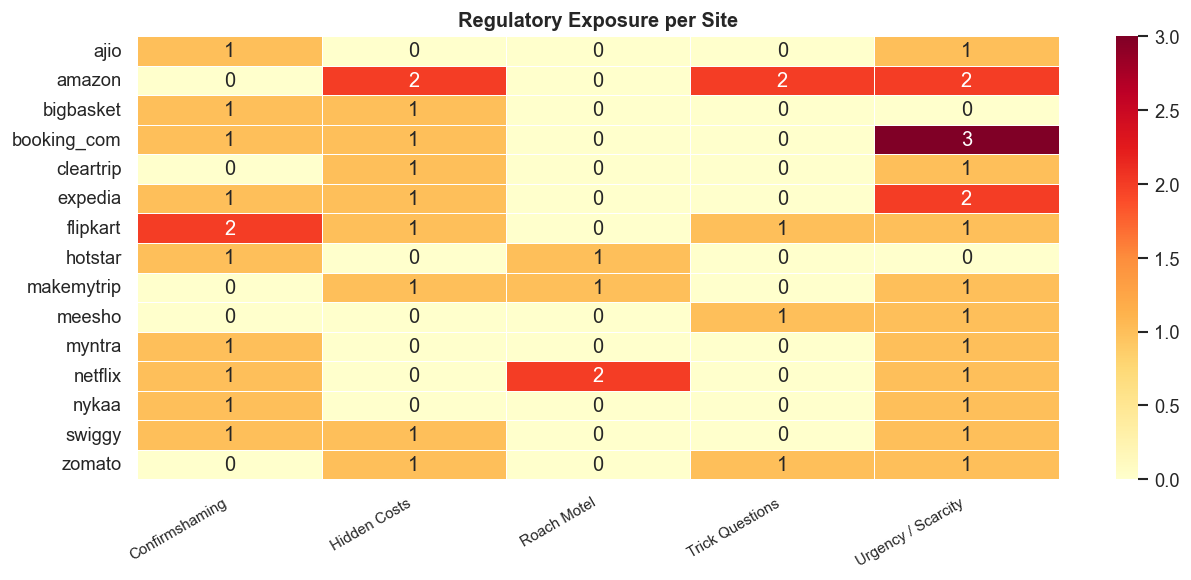

In [11]:
if len(findings_df) > 0:
    reg_pivot = findings_df.pivot_table(
        index='site', columns='pattern', values='severity', aggfunc='count'
    ).fillna(0)

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.heatmap(reg_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=0.3, ax=ax)
    ax.set_title('Regulatory Exposure per Site', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.xticks(rotation=30, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No findings to display.')

## Section 7 — Before / After Remediation

In [12]:
REMEDIATION_RULES = {
    'Urgency / Scarcity': [
        (r'only (\d+) (seats?|rooms?|items?|left|remaining)[^.]*', r'\1 \2 available'),
        (r'hurry[!,.]?\s*', ''),
        (r'act now[!,.]?\s*', ''),
        (r'flash sale ends today[!,.]?', 'Sale on selected items'),
        (r'\d+:\d+:\d+', 'today'),
        (r'limited time offer[!,.]?', 'Special offer'),
        (r'\d+ people viewing this', ''),
    ],
    'Confirmshaming': [
        (r"no[,]? (thanks[,]? )?i (hate|don.?t want|prefer not|dont want)", 'No thanks'),
        (r"no[,]? i prefer to pay (full price|more)", 'No thanks'),
        (r"i don.?t want to (improve|grow|save|get)", 'No thanks'),
    ],
    'Hidden Costs': [
        (r'(fee|charge) (added )?(at checkout|at step \d+)', 'included in price'),
        (r'price (shown )?(excludes|does not include) (taxes|fees)', 'price shown with taxes'),
        (r'taxes and (import )?fees calculated at (checkout|final step)', 'taxes shown before checkout'),
        (r'\(added at step \d+ of \d+\)', '(included in total)'),
    ],
    'Trick Questions': [
        (r'\(pre-?checked\)', '(unticked by default)'),
        (r'\(pre-?selected\)', '(unselected by default)'),
        (r'\(already checked\)', '(unticked by default)'),
        (r'auto-?renew enabled', 'auto-renew off by default'),
    ],
    'Roach Motel': [
        (r'cancel (by |via )?(calling|phoning|contacting) (our )?(retention |support )?team( only)?', 'cancel in account settings'),
        (r'cancellation requires (\d+-day )?written notice', 'cancel anytime'),
        (r'requires 30-day written notice', 'cancel anytime'),
    ],
    'Misdirection': [
        (r'opt-out buried (in )?settings', 'manage preferences — clearly visible'),
        (r'buried in settings', 'in account settings'),
    ],
}


def remediate(text, pattern_name):
    if pattern_name not in REMEDIATION_RULES:
        return text
    result = text
    for pat, repl in REMEDIATION_RULES[pattern_name]:
        result = re.sub(pat, repl, result, flags=re.IGNORECASE).strip()
    result = re.sub(r'\s+', ' ', result).strip(' ,')
    return result if result else text


if len(findings_df) > 0:
    findings_df['remediated_text'] = findings_df.apply(
        lambda r: remediate(r['ui_text'], r['pattern']), axis=1
    )
    findings_df['changed'] = (findings_df['ui_text'] != findings_df['remediated_text']).astype(int)

    print(f'Remediation rate: {findings_df["changed"].mean()*100:.0f}% of findings have a suggested fix\n')
    print(f'{"BEFORE":<55}  {"AFTER"}')
    print('-' * 110)
    for _, row in findings_df[findings_df['changed']==1].head(8).iterrows():
        b = row['ui_text'][:52] + ('...' if len(row['ui_text']) > 52 else '')
        a = row['remediated_text'][:50] + ('...' if len(row['remediated_text']) > 50 else '')
        print(f'{b:<55}  {a}')
else:
    print('No findings to remediate.')

Remediation rate: 53% of findings have a suggested fix

BEFORE                                                   AFTER
--------------------------------------------------------------------------------------------------------------
Only 2 rooms left at this price!                         2 rooms available
Deal expires in 00:14:32 book now                        Deal expires in today book now
No thanks I hate saving money                            No thanks saving money
Price shown excludes taxes and service fees              price shown with taxes and service fees
No I prefer to pay full price                            No thanks
Hurry Only 1 ticket left at this fare                    Only 1 ticket left at this fare
Only 3 left in stock order soon                          3 left available
Only 2 items left buy now                                2 items available


## Section 8 — Dark Score Ranking

In [13]:
WEIGHTS = {
    'label_roach_motel':    3.0,
    'label_hidden_costs':   2.5,
    'label_confirmshaming': 2.0,
    'label_trick_question': 2.0,
    'label_urgency':        1.5,
    'label_misdirection':   1.5,
}

scored = df[labelled_mask].copy()
scored[LABEL_COLS] = all_preds
scored['weighted'] = sum(scored[c] * w for c, w in WEIGHTS.items())

site_scores = scored.groupby(['site','sector']).agg(
    raw_score=('weighted','sum'),
    **{c.replace('label_','')+'_count': (c,'sum') for c in LABEL_COLS}
).reset_index()

max_s = site_scores['raw_score'].max()
site_scores['dark_score'] = (site_scores['raw_score'] / max_s * 100).round(1) if max_s > 0 else 0
site_scores['risk_level'] = pd.cut(
    site_scores['dark_score'], bins=[0,30,60,100], labels=['Low','Medium','High']
)
site_scores = site_scores.sort_values('dark_score', ascending=False)

print(site_scores[['site','sector','dark_score','risk_level']].to_string(index=False))

       site sector  dark_score risk_level
     amazon retail       100.0       High
   flipkart retail        83.3       High
    netflix   saas        79.2       High
booking_com travel        75.0       High
    expedia travel        62.5       High
 makemytrip travel        58.3     Medium
     swiggy   food        50.0     Medium
     zomato   food        50.0     Medium
    hotstar   saas        41.7     Medium
  bigbasket retail        37.5     Medium
  cleartrip travel        33.3     Medium
       ajio retail        29.2        Low
     meesho retail        29.2        Low
     myntra retail        29.2        Low
      nykaa retail        29.2        Low


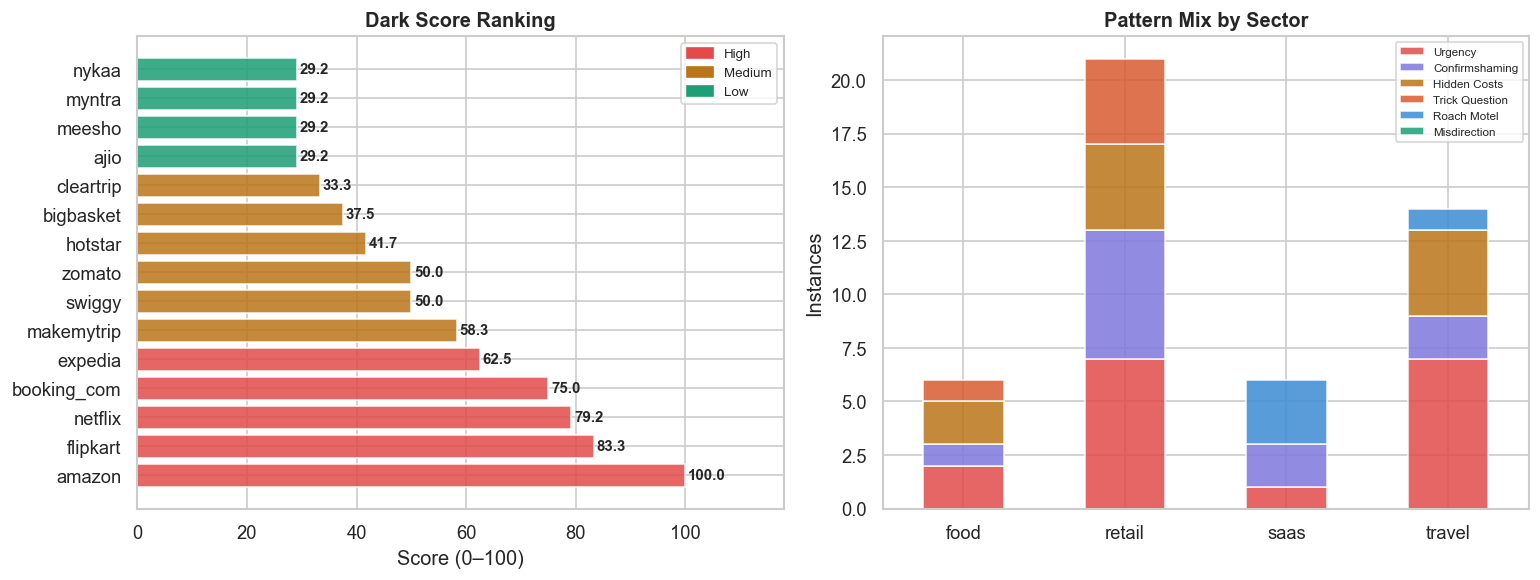

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

color_map = {'High':'#E24B4A', 'Medium':'#BA7517', 'Low':'#1D9E75'}
bar_colors = [color_map.get(str(r), '#94a3b8') for r in site_scores['risk_level']]
bars = axes[0].barh(site_scores['site'], site_scores['dark_score'],
                    color=bar_colors, alpha=0.85)
for bar, s in zip(bars, site_scores['dark_score']):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 f'{s}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Dark Score Ranking', fontweight='bold')
axes[0].set_xlabel('Score (0–100)')
axes[0].set_xlim(0, 118)
legend_p = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
axes[0].legend(handles=legend_p, fontsize=8)

sector_pat = scored.groupby('sector')[LABEL_COLS].sum()
sector_pat.columns = [c.replace('label_','').replace('_',' ').title() for c in sector_pat.columns]
sector_pat.plot(kind='bar', ax=axes[1],
                color=['#E24B4A','#7F77DD','#BA7517','#D85A30','#3B8BD4','#1D9E75'],
                alpha=0.85, stacked=True)
axes[1].set_title('Pattern Mix by Sector', fontweight='bold')
axes[1].set_ylabel('Instances')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Section 9 — Power BI Export

In [15]:
today = str(date.today())

# Export 1: site KPI scores
export_sites = site_scores.copy()
export_sites['risk_level']   = export_sites['risk_level'].astype(str)
export_sites['report_date']  = today
export_sites.to_csv('powerbi_site_scores.csv', index=False)
print(f'powerbi_site_scores.csv  — {len(export_sites)} rows')

# Export 2: findings with regulation
if len(findings_df) > 0:
    export_findings = findings_df[['site','sector','ui_text','pattern','severity','dsa','ftc']].copy()
    export_findings['report_date'] = today
    export_findings.to_csv('powerbi_findings.csv', index=False)
    print(f'powerbi_findings.csv     — {len(export_findings)} rows')

    # Export 3: remediation
    export_remed = findings_df[['site','sector','pattern','severity','ui_text','remediated_text','changed']].copy()
    export_remed['report_date'] = today
    export_remed.to_csv('powerbi_remediation.csv', index=False)
    print(f'powerbi_remediation.csv  — {len(export_remed)} rows')
else:
    print('No findings to export yet. Run model on labelled data first.')

print('\nAll CSV files saved in your project folder. Open Power BI and load them.')

powerbi_site_scores.csv  — 15 rows
powerbi_findings.csv     — 47 rows
powerbi_remediation.csv  — 47 rows

All CSV files saved in your project folder. Open Power BI and load them.


## Section 10 — Power BI Setup Guide

### Load data
```
Home → Get Data → Text/CSV → load all 3 CSV files
```

### Relationships (Model view)
```
powerbi_site_scores[site]  →  powerbi_findings[site]
powerbi_site_scores[site]  →  powerbi_remediation[site]
```

### Page 1 — Executive Summary
- 4 KPI cards: Total sites · Avg dark score · High-risk count · Total findings
- Horizontal bar chart: site vs dark_score, colored by risk_level
- Donut chart: pattern type distribution
- Slicer: sector

### Page 2 — Regulation Exposure
- Matrix: rows = site, columns = pattern, values = count
  - Conditional format: 0 = white, 1–2 = amber, 3+ = red
- Table: site, pattern, severity, dsa clause
- Slicer: severity

### Page 3 — Remediation Tracker
- Table: site, pattern, ui_text (red), remediated_text (green)
- KPI: remediation rate = changed / total
- Slicer: site

### DAX measures
```dax
Avg Dark Score   = AVERAGE(powerbi_site_scores[dark_score])
High Risk Sites  = COUNTROWS(FILTER(powerbi_site_scores, powerbi_site_scores[risk_level] = "High"))
Total Findings   = COUNTROWS(powerbi_findings)
Remediation Rate = DIVIDE(COUNTROWS(FILTER(powerbi_remediation, powerbi_remediation[changed] = 1)), COUNTROWS(powerbi_remediation))
```